## MLIP Predictions vs DFT

__This Notebook Compares Different MLIP Predictions for Energy and Forces For a Relaxation (CO3 on Ag) to DFT Calculationions for Energy and Forces.__

Based off of the three most accurate models for catalysts in the paper "How accurate are foundational machine learning interatomic potentials for heterogeneous catalysis?" (https://arxiv.org/pdf/2512.16702), the models compared here are:


1. __eSEN__ --An equivariant graph neural network that builds upon the structural principles of eSCN and Equiformer. By optimizing the internal mathematics of its convolution blocks, eSEN enforces rigorous physical symmetry constraints to guarantee smooth potential energy surfaces and excellent energy conservation during molecular dynamics rollouts. For surface-catalysis evaluations, it utilizes large-scale checkpoints (such as 30M parameter models) pre-trained across diverse materials and common surface-adsorbate repositories including MPTrj, OMat24, OAM, and OC25. __The pre-training for eSEN in this notebook is OMat24 +MPtrj +sAlex___
2. __UMA__ --An advanced multi-task expansion of the eSEN framework that integrates a Mixture of Linear Experts (MoE) to scale model capacity while maintaining high GPU inference throughput. Engineered to handle complex interfacial chemistry, UMA incorporates global graph embeddings representing total system charge, spin multiplicity, and the reference DFT functional. This multi-task awareness allows the architecture to safely learn from a heterogeneous mix of dataset origins, including extended OC20, ODAC25, OMat24, OMC25, and OMol25. __The pre-taining dataset for UMA in this notebook is OMat24__
3. __Orb__ --A universal interatomic potential family designed to maximize scalability and throughput by intentionally departing from strict physical equivariance constraints in its graph backbone. The architecture utilizes denoising diffusion pre-training followed by structural fine-tuning, utilizing a regularization scheme called equigrad to physically approximate equivariance. Its specific zero-shot accuracy profiles are governed by clear parameter combinations evaluating model conservatism (direct vs. conservative gradients), neighbor interaction limits (20 to infinity), and common data mixtures across MPTrj, Alex, and OMat24. __The pre-training dataset for Orb in this notebook is OMat24__

## One-Time Setup — Create the three conda environments

Before running this notebook, each model needs its own conda environment.  
Run the commands below in **Anaconda Prompt** (search "Anaconda Prompt" in the  
Windows Start menu). Run each block once, line by line.

These commands are documentation only — they do **not** run from inside the  
notebook. Copy them into Anaconda Prompt.

---

### Step A — Find your conda path (needed for Section 0)

```bash
where conda
```
Copy the line ending in `Scripts\conda.exe` and paste it into `CONDA_EXE`  
in Section 0 below.

---

### Step B — Accept model licenses on Hugging Face (one time, in a browser)

1. Create a free account at https://huggingface.co
2. Accept the eSEN license at https://huggingface.co/facebook/OMAT24 (click *Agree*)
3. Request access to UMA at https://huggingface.co/facebook/UMA (click *Agree*)
4. Create an access token at https://huggingface.co/settings/tokens  
   (New token → Read role → copy it into `HF_TOKEN` in Section 0)

---

### Step C — eSEN environment (fairchem **v1** — older, pinned dependencies)

eSEN-30M-OAM is a fairchem version-1 model, so this environment must use the  
older fairchem plus a few pinned packages. Note the torch wheel URL must match  
the torch version that fairchem installs (see the note after the block).

```bash
conda create -n eSEN_CPU_2 python=3.11 -y
conda activate eSEN_CPU_2
pip install fairchem-core==1.10.0
pip install "scipy<1.15"
pip install ase huggingface_hub ipykernel
python -c "import torch; print(torch.__version__)"
```

The last line prints your torch version (e.g. `2.4.1+cpu`). Put that exact  
version into the wheel URL below, then run it to install the PyG extensions:

```bash
pip install torch_scatter torch_sparse torch_cluster -f https://data.pyg.org/whl/torch-2.4.1+cpu.html
```

Finally, register the environment as a Jupyter kernel:

```bash
python -m ipykernel install --user --name eSEN_CPU_2 --display-name "Python (eSEN_CPU_2)"
```

---

### Step D — UMA environment (fairchem **v2** — current)

```bash
conda create -n UMA_CPU python=3.11 -y
conda activate UMA_CPU
pip install fairchem-core
pip install ase ipykernel
python -m ipykernel install --user --name UMA_CPU --display-name "Python (UMA_CPU)"
```

---

### Step E — Orb environment (orb-models)

```bash
conda create -n Orb_CPU python=3.11 -y
conda activate Orb_CPU
pip install orb-models
pip install ase ipykernel
python -m ipykernel install --user --name Orb_CPU --display-name "Python (Orb_CPU)"
```

---

### Step F — Verify all three environments are registered

```bash
jupyter kernelspec list
```
You should see `eSEN_CPU_2`, `UMA_CPU`, and `Orb_CPU` in the list.

**Important:** the environment names you create here must exactly match the  
`*_ENV_NAME` variables in Section 0. If you name them differently, update  
Section 0 to match.

---

### Quick troubleshooting

The eSEN (fairchem v1) environment is the most likely to need extra pins,  
because it is an older library running among newer dependencies. If eSEN fails  
with an `ImportError: cannot import name 'X' from 'Y'`, downgrade that one  
package (e.g. `pip install "Y<version"`) until the import works. The errors  
we already pinned for: `torch_scatter` (PyG wheels) and `scipy.sph_harm`  
(`scipy<1.15`).

---

## Section 0 — User Configuration
**Edit the variables below. Nothing else in this notebook needs to be changed.**

In [ ]:
# =============================================================================
#                         USER CONFIGURATION
# =============================================================================

# ── Data ─────────────────────────────────────────────────────────────────────
# Full or relative path to your vasprun.xml file
VASPRUN_PATH = r'vasprun_CO3_Ag.xml'   # <-- Change this to your file path

# A short label for this dataset (used in plot titles and filenames)
DATASET_LABEL = 'CO3 on Ag'     # <-- Change this to describe your system

# ── Hugging Face Token ───────────────────────────────────────────────────────
# Required for downloading eSEN and UMA model weights from Hugging Face
HF_TOKEN = 'TOKEN GOES HERE'  # <-- Paste your Hugging Face token

# ── Anaconda Path ────────────────────────────────────────────────────────────
# Full path to your conda executable. Find it by opening Anaconda Prompt
# and typing: where conda
CONDA_EXE = r'C:\Users\Blake\anaconda3\Scripts\conda.exe'

# ── Conda Environment Names ─────────────────────────────────────────────────
# Must match the names you created with: conda create -n <name>
ESEN_ENV_NAME = 'eSEN_CPU_2'       # <-- Name of your eSEN conda environment
UMA_ENV_NAME  = 'UMA_CPU'        # <-- Name of your UMA conda environment
ORB_ENV_NAME  = 'Orb_CPU'        # <-- Name of your Orb conda environment

# ── eSEN Settings (Meta fairchem library v1 — OMAT24 checkpoint) ──────────
# eSEN-30M-OAM is a fairchem VERSION 1 model. The eSEN conda environment
# MUST have fairchem-core v1.x installed (NOT v2). See setup notes below.
# You must also accept the OMAT24 license on
# https://huggingface.co/facebook/OMAT24 before this will work.
ESEN_HF_REPO    = 'facebook/OMAT24'       # HuggingFace repository
ESEN_HF_FILE    = 'esen_30m_oam.pt'       # Checkpoint filename

# ── UMA Settings (Meta fairchem library v2) ─────────────────────────────────
# Model name as registered in fairchem's pretrained_mlip registry
UMA_MODEL_NAME = 'uma-s-1p2'     # Options: 'uma-s-1p1', 'uma-s-1p2', 'uma-m-1p1'
UMA_TASK_NAME  = 'omat'          # Options: 'omat', 'oc20', 'omol', 'odac', 'omc'

# ── OrbMol Settings (Orbital Materials library) ─────────────────────────────
# OrbMol extends Orb to molecular systems. Uses orb-models library.
# See: https://huggingface.co/Orbital-Materials/OrbMol
ORB_MODEL_NAME = 'orb-v3-conservative-inf-omat'
# Options: 'orb-v3-conservative-omol' (default), 'orb-v3-direct-omol'

# OrbMol requires the total charge and spin multiplicity of your system.
# For a neutral closed-shell system, use charge=0 and spin=1.
# Adjust these to match the actual chemistry of your structure.
ORB_CHARGE = 0    # Total charge of the system
ORB_SPIN   = 1    # Spin multiplicity (1 = singlet, 2 = doublet, ...)

# ── Which models to run ─────────────────────────────────────────────────────
# Set to True to run, False to skip
RUN_ESEN = True
RUN_UMA  = True
RUN_ORB  = True

# ── MLIP Relaxation Settings (Experiment 2) ─────────────────────────────────
# In addition to single-point predictions (Experiment 1), each model can take
# ONLY the first DFT frame and relax the structure itself until forces are
# below the convergence threshold. This tests whether the model finds the same
# minimum geometry and energy that DFT did.
RUN_RELAXATION = True            # Set False to skip the self-relaxation experiment
FMAX           = 0.05            # Force convergence criterion in eV/Angstrom
                                 # (0.05 matches a typical VASP EDIFFG = -0.05)
MAX_RELAX_STEPS = 500            # Safety cap on optimizer steps per model
OPTIMIZER       = 'BFGS'         # ASE optimizer: 'BFGS' or 'FIRE'

# ── Output ───────────────────────────────────────────────────────────────────
OUTPUT_DIR   = 'results'          # Folder for .npz result files
SCRIPTS_DIR  = 'scripts'          # Folder for auto-generated model scripts
SAVE_PLOTS   = True               # Save plot images as PNG files
FIGURE_DPI   = 140                # Resolution for saved figures

# =============================================================================
#                     END OF USER CONFIGURATION
# =============================================================================

## Section 1 — Create output directories and generate model runner scripts
This cell writes three standalone Python scripts to disk.  
Each script is designed to run inside its own conda environment.

In [21]:
import os

# Create output folders if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SCRIPTS_DIR, exist_ok=True)

print(f"Output directory : {os.path.abspath(OUTPUT_DIR)}")
print(f"Scripts directory: {os.path.abspath(SCRIPTS_DIR)}")

Output directory : c:\Users\Blake\OneDrive\Desktop\Python_REU\TulaneREU\MLIPs_vs_DFT_relaxation\results
Scripts directory: c:\Users\Blake\OneDrive\Desktop\Python_REU\TulaneREU\MLIPs_vs_DFT_relaxation\scripts


In [22]:
# =====================================================================
# SCRIPT 1: eSEN runner (Meta fairchem library + OMAT24 checkpoint)
# =====================================================================
# eSEN-30M-OAM uses the same fairchem library as UMA, but loads a
# specific checkpoint file downloaded from HuggingFace.
# The user MUST accept the OMAT24 license on HuggingFace first.

esen_script = r'''
"""eSEN Model Runner — Meta fairchem library (OMAT24 checkpoint)
Auto-generated by MLIP_vs_DFT_Comparison.ipynb
Runs inside the eSEN conda environment.
"""
import sys
import os
import numpy as np

# ── Parse command-line arguments ──────────────────────────────────────
vasprun_path = sys.argv[1]    # Path to vasprun.xml
output_path  = sys.argv[2]    # Path to save .npz results
hf_repo      = sys.argv[3]    # HuggingFace repo (e.g. 'facebook/OMAT24')
hf_file      = sys.argv[4]    # Checkpoint filename (e.g. 'esen_30m_oam.pt')
hf_token     = sys.argv[5]    # HuggingFace API token
do_relax     = sys.argv[6] == 'True'   # Whether to run self-relaxation
fmax         = float(sys.argv[7])      # Force convergence (eV/Angstrom)
max_steps    = int(sys.argv[8])        # Max optimizer steps
optimizer    = sys.argv[9]             # 'BFGS' or 'FIRE'

# ── Set HuggingFace token ────────────────────────────────────────────
os.environ["HF_TOKEN"] = hf_token

# ── Step 1: Download the eSEN checkpoint from HuggingFace ────────────
from huggingface_hub import hf_hub_download

print(f"Downloading {hf_file} from {hf_repo}...")
print("(If this fails, make sure you accepted the OMAT24 license at")
print(" https://huggingface.co/facebook/OMAT24 )")

checkpoint_path = hf_hub_download(
    repo_id=hf_repo,
    filename=hf_file,
    token=hf_token
)
print(f"Checkpoint downloaded to: {checkpoint_path}")

# ── Step 2: Load eSEN via fairchem v1's OCPCalculator ───────────────
# eSEN-30M-OAM is a fairchem v1 model, so we use the v1 OCPCalculator API.
import ase.io
from fairchem.core import OCPCalculator

print(f"Loading eSEN-30M-OAM from checkpoint...")
calculator = OCPCalculator(checkpoint_path=checkpoint_path, cpu=True)
print("eSEN model loaded successfully.")

# ── Step 3: Read ionic step frames from vasprun.xml ──────────────────
print(f"Reading frames from {vasprun_path}...")
frames = ase.io.read(vasprun_path, index=':')
n_frames = len(frames)
print(f"Found {n_frames} ionic steps.")

# ── Step 4: Loop through frames — extract DFT energies + ML predictions
dft_energies = []
ml_energies  = []

print(f"Processing {n_frames} frames through eSEN...")
for i, frame in enumerate(frames):
    # DFT energy is stored in the atoms object from vasprun
    dft_energies.append(frame.get_potential_energy())

    # Create a copy and attach the ML calculator
    ml_frame = frame.copy()
    ml_frame.calc = calculator
    ml_energies.append(ml_frame.get_potential_energy())

    # Progress update every ~20% of frames
    if (i + 1) % max(1, n_frames // 5) == 0 or i == n_frames - 1:
        print(f"  Step {i + 1}/{n_frames}")

# ── Step 5: Self-relaxation from the first frame (Experiment 2) ──────
# Give the model ONLY the first DFT geometry and let it relax the structure
# itself until forces converge. This tests whether the model finds the same
# minimum that DFT found.
relax_energies = np.array([])   # ML energy at each relaxation step
relax_final_positions = np.array([])
relax_converged = False
relax_n_steps = 0

if do_relax:
    from ase.optimize import BFGS, FIRE
    from ase.constraints import FixAtoms

    print(f"\nStarting self-relaxation from first frame (fmax={fmax} eV/A)...")

    # Start from a fresh copy of the FIRST frame only
    relax_atoms = frames[0].copy()
    relax_atoms.calc = calculator

    # Preserve any selective-dynamics constraints from the DFT setup
    # (frozen bottom slab layers, etc.) so positions-only relaxation matches.
    if frames[0].constraints:
        relax_atoms.set_constraint(frames[0].constraints)

    # Record energy at each optimizer step via an attached callback
    relax_energy_list = []
    def _record():
        relax_energy_list.append(relax_atoms.get_potential_energy())

    # Choose optimizer
    Opt = FIRE if optimizer.upper() == 'FIRE' else BFGS
    dyn = Opt(relax_atoms)
    dyn.attach(_record, interval=1)

    # Run until forces < fmax or we hit the step cap
    dyn.run(fmax=fmax, steps=max_steps)

    relax_energies = np.array(relax_energy_list)
    relax_final_positions = relax_atoms.get_positions()
    relax_n_steps = len(relax_energy_list)
    # Converged if the max force is now below the threshold
    final_fmax = np.sqrt((relax_atoms.get_forces() ** 2).sum(axis=1).max())
    relax_converged = bool(final_fmax < fmax)
    print(f"Relaxation finished: {relax_n_steps} steps, "
          f"final fmax={final_fmax:.4f} eV/A, converged={relax_converged}")

# ── Step 6: Save results ─────────────────────────────────────────────
# Save both Experiment 1 (single-point) and Experiment 2 (self-relaxation).
# Also save the DFT final geometry so the notebook can compute RMSD.
np.savez(
    output_path,
    dft_energies=np.array(dft_energies),
    ml_energies=np.array(ml_energies),
    relax_energies=relax_energies,
    relax_final_positions=relax_final_positions,
    relax_converged=relax_converged,
    relax_n_steps=relax_n_steps,
    dft_final_positions=frames[-1].get_positions(),
)

print(f"\n==================== eSEN COMPLETE ====================")
print(f"Saved {n_frames} single-point pairs to {output_path}")
if do_relax:
    print(f"Saved self-relaxation trajectory ({relax_n_steps} steps)")
print(f"=======================================================")
'''

esen_script_path = os.path.join(SCRIPTS_DIR, 'run_esen.py')
with open(esen_script_path, 'w') as f:
    f.write(esen_script)
print(f"Wrote: {esen_script_path}")

Wrote: scripts\run_esen.py


In [23]:
# =====================================================================
# SCRIPT 2: UMA runner (Meta fairchem library, PyTorch-based)
# =====================================================================
# This script uses the same pattern from the user's previous project:
# FAIRChemCalculator with pretrained_mlip, ASE calculator interface.

uma_script = r'''
"""UMA Model Runner — Meta fairchem library (PyTorch-based)
Auto-generated by MLIP_vs_DFT_Comparison.ipynb
Runs inside the UMA conda environment.
"""
import sys
import os
import numpy as np

# ── Parse command-line arguments ──────────────────────────────────────
vasprun_path = sys.argv[1]    # Path to vasprun.xml
output_path  = sys.argv[2]    # Path to save .npz results
model_name   = sys.argv[3]    # e.g. 'uma-s-1p2'
task_name    = sys.argv[4]    # e.g. 'omat', 'oc20'
hf_token     = sys.argv[5]    # HuggingFace API token
do_relax     = sys.argv[6] == 'True'   # Whether to run self-relaxation
fmax         = float(sys.argv[7])      # Force convergence (eV/Angstrom)
max_steps    = int(sys.argv[8])        # Max optimizer steps
optimizer    = sys.argv[9]             # 'BFGS' or 'FIRE'

# ── Set HuggingFace token ────────────────────────────────────────────
os.environ["HF_TOKEN"] = hf_token

# ── Step 1: Load UMA model via fairchem ──────────────────────────────
import ase.io
from fairchem.core import FAIRChemCalculator, pretrained_mlip

print(f"Loading UMA model: {model_name} (task: {task_name})...")
predictor = pretrained_mlip.get_predict_unit(model_name)
calculator = FAIRChemCalculator(predictor, task_name=task_name)
print("UMA model loaded successfully.")

# ── Step 2: Read ionic step frames from vasprun.xml ──────────────────
print(f"Reading frames from {vasprun_path}...")
frames = ase.io.read(vasprun_path, index=':')
n_frames = len(frames)
print(f"Found {n_frames} ionic steps.")

# ── Step 3: Loop through frames — extract DFT energies + ML predictions
dft_energies = []
ml_energies  = []

print(f"Processing {n_frames} frames through UMA...")
for i, frame in enumerate(frames):
    # DFT energy is stored in the atoms object from vasprun
    dft_energies.append(frame.get_potential_energy())

    # Create a copy and attach the ML calculator
    ml_frame = frame.copy()
    ml_frame.calc = calculator
    ml_energies.append(ml_frame.get_potential_energy())

    # Progress update every ~20% of frames
    if (i + 1) % max(1, n_frames // 5) == 0 or i == n_frames - 1:
        print(f"  Step {i + 1}/{n_frames}")

# ── Step 4: Self-relaxation from the first frame (Experiment 2) ──────
# Give the model ONLY the first DFT geometry and let it relax the structure
# itself until forces converge.
relax_energies = np.array([])
relax_final_positions = np.array([])
relax_converged = False
relax_n_steps = 0

if do_relax:
    from ase.optimize import BFGS, FIRE

    print(f"\nStarting self-relaxation from first frame (fmax={fmax} eV/A)...")

    relax_atoms = frames[0].copy()
    relax_atoms.calc = calculator

    # Preserve any selective-dynamics constraints from the DFT setup
    if frames[0].constraints:
        relax_atoms.set_constraint(frames[0].constraints)

    relax_energy_list = []
    def _record():
        relax_energy_list.append(relax_atoms.get_potential_energy())

    Opt = FIRE if optimizer.upper() == 'FIRE' else BFGS
    dyn = Opt(relax_atoms)
    dyn.attach(_record, interval=1)
    dyn.run(fmax=fmax, steps=max_steps)

    relax_energies = np.array(relax_energy_list)
    relax_final_positions = relax_atoms.get_positions()
    relax_n_steps = len(relax_energy_list)
    final_fmax = np.sqrt((relax_atoms.get_forces() ** 2).sum(axis=1).max())
    relax_converged = bool(final_fmax < fmax)
    print(f"Relaxation finished: {relax_n_steps} steps, "
          f"final fmax={final_fmax:.4f} eV/A, converged={relax_converged}")

# ── Step 5: Save results ─────────────────────────────────────────────
np.savez(
    output_path,
    dft_energies=np.array(dft_energies),
    ml_energies=np.array(ml_energies),
    relax_energies=relax_energies,
    relax_final_positions=relax_final_positions,
    relax_converged=relax_converged,
    relax_n_steps=relax_n_steps,
    dft_final_positions=frames[-1].get_positions(),
)

print(f"\n==================== UMA COMPLETE =====================")
print(f"Saved {n_frames} single-point pairs to {output_path}")
if do_relax:
    print(f"Saved self-relaxation trajectory ({relax_n_steps} steps)")
print(f"=======================================================")
'''

uma_script_path = os.path.join(SCRIPTS_DIR, 'run_uma.py')
with open(uma_script_path, 'w') as f:
    f.write(uma_script)
print(f"Wrote: {uma_script_path}")

Wrote: scripts\run_uma.py


In [24]:
# =====================================================================
# SCRIPT 3: OrbMol runner (Orbital Materials library, PyTorch-based)
# =====================================================================
# OrbMol extends Orb-v3 to molecular systems. Uses the orb-models lib.
# See: https://huggingface.co/Orbital-Materials/OrbMol
# NOTE: Orb says Windows support is "not guaranteed" — if this fails,
#       it may be an OS compatibility issue, not a code bug.

orb_script = r'''
"""OrbMol Model Runner — Orbital Materials library (PyTorch-based)
Auto-generated by MLIP_vs_DFT_Comparison.ipynb
Runs inside the Orb conda environment.
"""
import sys
import os
import numpy as np

# ── Parse command-line arguments ──────────────────────────────────────
vasprun_path = sys.argv[1]    # Path to vasprun.xml
output_path  = sys.argv[2]    # Path to save .npz results
model_name   = sys.argv[3]    # e.g. 'orb-v3-conservative-omol'
charge       = int(sys.argv[4])  # Total charge of the system
spin         = int(sys.argv[5])  # Spin multiplicity
do_relax     = sys.argv[6] == 'True'   # Whether to run self-relaxation
fmax         = float(sys.argv[7])      # Force convergence (eV/Angstrom)
max_steps    = int(sys.argv[8])        # Max optimizer steps
optimizer    = sys.argv[9]             # 'BFGS' or 'FIRE'

# ── Step 1: Load OrbMol model ────────────────────────────────────────
import torch
# Disable torch.compile — on Windows it needs the MSVC C++ compiler (cl.exe),
# which usually isn't installed. Disabling it avoids that requirement.
try:
    torch._dynamo.disable()
except Exception:
    pass

import ase.io
from orb_models.forcefield import pretrained
from orb_models.forcefield.calculator import ORBCalculator

# Map human-readable model names to their loader functions
ORB_LOADERS = {
    'orb-v3-conservative-omol'     : pretrained.orb_v3_conservative_omol,
    'orb-v3-direct-omol'           : pretrained.orb_v3_direct_omol,
    'orb-v3-conservative-inf-omat' : pretrained.orb_v3_conservative_inf_omat,
    'orb-v3-direct-inf-omat'       : pretrained.orb_v3_direct_inf_omat,
}

print(f"Loading Orb model: {model_name}...")
loader_fn = ORB_LOADERS.get(model_name)
if loader_fn is None:
    print(f"ERROR: Unknown model '{model_name}'.")
    print(f"Available models: {list(ORB_LOADERS.keys())}")
    sys.exit(1)

# Load the model — pass compile=False to avoid the C++ compiler requirement.
# Some versions don't accept the 'compile' argument, so fall back if needed.
try:
    result = loader_fn(device="cpu", compile=False)
except TypeError:
    result = loader_fn(device="cpu")

# Handle both old API (returns tuple) and new API (returns single object)
if isinstance(result, tuple):
    orbff, atoms_adapter = result
    calculator = ORBCalculator(orbff, atoms_adapter=atoms_adapter, device="cpu")
else:
    orbff = result
    calculator = ORBCalculator(orbff, device="cpu")
print("Orb model loaded successfully.")

# ── Step 2: Read ionic step frames from vasprun.xml ──────────────────
print(f"Reading frames from {vasprun_path}...")
frames = ase.io.read(vasprun_path, index=':')
n_frames = len(frames)
print(f"Found {n_frames} ionic steps.")

# ── Step 3: Loop through frames — extract DFT energies + ML predictions
dft_energies = []
ml_energies  = []

print(f"Processing {n_frames} frames through OrbMol...")
for i, frame in enumerate(frames):
    # DFT energy is stored in the atoms object from vasprun
    dft_energies.append(frame.get_potential_energy())

    # Create a copy and attach the ML calculator
    ml_frame = frame.copy()
    # OrbMol requires charge and spin multiplicity in atoms.info
    ml_frame.info['charge'] = charge
    ml_frame.info['spin'] = spin
    ml_frame.calc = calculator
    ml_energies.append(ml_frame.get_potential_energy())

    # Progress update every ~20% of frames
    if (i + 1) % max(1, n_frames // 5) == 0 or i == n_frames - 1:
        print(f"  Step {i + 1}/{n_frames}")

# ── Step 4: Self-relaxation from the first frame (Experiment 2) ──────
# Give the model ONLY the first DFT geometry and let it relax the structure
# itself until forces converge. OrbMol-style models need charge/spin set.
relax_energies = np.array([])
relax_final_positions = np.array([])
relax_converged = False
relax_n_steps = 0

if do_relax:
    from ase.optimize import BFGS, FIRE

    print(f"\nStarting self-relaxation from first frame (fmax={fmax} eV/A)...")

    relax_atoms = frames[0].copy()
    # Set charge/spin (required by molecular Orb models, ignored by omat models)
    relax_atoms.info['charge'] = charge
    relax_atoms.info['spin'] = spin
    relax_atoms.calc = calculator

    # Preserve any selective-dynamics constraints from the DFT setup
    if frames[0].constraints:
        relax_atoms.set_constraint(frames[0].constraints)

    relax_energy_list = []
    def _record():
        relax_energy_list.append(relax_atoms.get_potential_energy())

    Opt = FIRE if optimizer.upper() == 'FIRE' else BFGS
    dyn = Opt(relax_atoms)
    dyn.attach(_record, interval=1)
    dyn.run(fmax=fmax, steps=max_steps)

    relax_energies = np.array(relax_energy_list)
    relax_final_positions = relax_atoms.get_positions()
    relax_n_steps = len(relax_energy_list)
    final_fmax = np.sqrt((relax_atoms.get_forces() ** 2).sum(axis=1).max())
    relax_converged = bool(final_fmax < fmax)
    print(f"Relaxation finished: {relax_n_steps} steps, "
          f"final fmax={final_fmax:.4f} eV/A, converged={relax_converged}")

# ── Step 5: Save results ─────────────────────────────────────────────
np.savez(
    output_path,
    dft_energies=np.array(dft_energies),
    ml_energies=np.array(ml_energies),
    relax_energies=relax_energies,
    relax_final_positions=relax_final_positions,
    relax_converged=relax_converged,
    relax_n_steps=relax_n_steps,
    dft_final_positions=frames[-1].get_positions(),
)

print(f"\n==================== OrbMol COMPLETE ==================")
print(f"Saved {n_frames} single-point pairs to {output_path}")
if do_relax:
    print(f"Saved self-relaxation trajectory ({relax_n_steps} steps)")
print(f"=======================================================")
'''

orb_script_path = os.path.join(SCRIPTS_DIR, 'run_orb.py')
with open(orb_script_path, 'w') as f:
    f.write(orb_script)
print(f"Wrote: {orb_script_path}")

Wrote: scripts\run_orb.py


## Section 2 — Run the models
Each cell below calls one model script inside its correct conda environment.  
Results are saved as `.npz` files in the output directory.  

**If a cell fails**, the error output will appear below it — read the last few  
lines for the actual Python error from that environment.

In [25]:
import subprocess
import sys

def run_model_script(env_name, script_path, args, model_label):
    """Run a Python script inside a specific conda environment.
    
    Uses 'conda run' to execute the script in the target environment
    without needing to activate it first.
    
    Parameters
    ----------
    env_name : str
        Name of the conda environment (e.g. 'UMA_CPU')
    script_path : str
        Path to the .py script to run
    args : list of str
        Command-line arguments to pass to the script
    model_label : str
        Human-readable name for print messages (e.g. 'UMA')
    
    Returns
    -------
    bool
        True if the script ran successfully, False otherwise
    """
    # Build the command using the full path to conda from Section 0
    cmd = [
        CONDA_EXE, 'run',         # Full path to conda executable
        '-n', env_name,           # Target environment
        'python', script_path     # The script to execute
    ] + args
    
    print(f"{'='*60}")
    print(f"  Running {model_label} in environment: {env_name}")
    print(f"{'='*60}")
    print(f"Using conda at: {CONDA_EXE}")
    print(f"Environment:    {env_name}")
    print(f"Script:         {script_path}\n")
    
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=1800  # 30 minute timeout per model
        )
        
        # Print the script's stdout (progress messages)
        if result.stdout:
            print(result.stdout)
        
        # If it failed, print stderr too
        if result.returncode != 0:
            print(f"\n❌ {model_label} FAILED (exit code {result.returncode})")
            if result.stderr:
                print("--- Error output ---")
                print(result.stderr[-2000:])  # Last 2000 chars of error
            return False
        else:
            print(f"✅ {model_label} completed successfully.")
            return True
            
    except FileNotFoundError:
        print(f"\n❌ ERROR: conda not found at: {CONDA_EXE}")
        print(f"Open Anaconda Prompt, type 'where conda', and paste the")
        print(f"path into CONDA_EXE in Section 0 of this notebook.")
        return False
    except subprocess.TimeoutExpired:
        print(f"\n❌ {model_label} timed out after 30 minutes.")
        return False

print("Helper function ready.")

Helper function ready.


In [26]:
# ── Run eSEN ─────────────────────────────────────────────────────────
esen_result_path = os.path.join(OUTPUT_DIR, 'esen_results.npz')

if RUN_ESEN:
    esen_success = run_model_script(
        env_name=ESEN_ENV_NAME,
        script_path=os.path.join(SCRIPTS_DIR, 'run_esen.py'),
        args=[
            VASPRUN_PATH,
            esen_result_path,
            ESEN_HF_REPO,
            ESEN_HF_FILE,
            HF_TOKEN,
            str(RUN_RELAXATION),
            str(FMAX),
            str(MAX_RELAX_STEPS),
            OPTIMIZER
        ],
        model_label='eSEN'
    )
else:
    print("eSEN skipped (RUN_ESEN = False)")
    esen_success = False

  Running eSEN in environment: eSEN_CPU_2
Using conda at: C:\Users\Blake\anaconda3\Scripts\conda.exe
Environment:    eSEN_CPU_2
Script:         scripts\run_esen.py

(If this fails, make sure you accepted the OMAT24 license at
 https://huggingface.co/facebook/OMAT24 )
Checkpoint downloaded to: C:\Users\Blake\.cache\huggingface\hub\models--facebook--OMAT24\snapshots\8a5a78c7ba7b250a17e85fe85943c4608499d895\esen_30m_oam.pt
Loading eSEN-30M-OAM from checkpoint...
eSEN model loaded successfully.
Reading frames from vasprun_CO3_Ag.xml...
Found 379 ionic steps.
Processing 379 frames through eSEN...
  Step 75/379
  Step 150/379
  Step 225/379
  Step 300/379
  Step 375/379
  Step 379/379

Starting self-relaxation from first frame (fmax=0.05 eV/A)...
      Step     Time          Energy          fmax
BFGS:    0 11:22:45      -70.842484        0.192385
BFGS:    1 11:22:46      -70.845093        0.178431
BFGS:    2 11:22:47      -70.862823        0.409181
BFGS:    3 11:22:48      -70.873703        

In [27]:
# ── Run UMA ──────────────────────────────────────────────────────────
uma_result_path = os.path.join(OUTPUT_DIR, 'uma_results.npz')

if RUN_UMA:
    uma_success = run_model_script(
        env_name=UMA_ENV_NAME,
        script_path=os.path.join(SCRIPTS_DIR, 'run_uma.py'),
        args=[
            VASPRUN_PATH,
            uma_result_path,
            UMA_MODEL_NAME,
            UMA_TASK_NAME,
            HF_TOKEN,
            str(RUN_RELAXATION),
            str(FMAX),
            str(MAX_RELAX_STEPS),
            OPTIMIZER
        ],
        model_label='UMA'
    )
else:
    print("UMA skipped (RUN_UMA = False)")
    uma_success = False

  Running UMA in environment: UMA_CPU
Using conda at: C:\Users\Blake\anaconda3\Scripts\conda.exe
Environment:    UMA_CPU
Script:         scripts\run_uma.py

Loading UMA model: uma-s-1p2 (task: omat)...
UMA model loaded successfully.
Reading frames from vasprun_CO3_Ag.xml...
Found 379 ionic steps.
Processing 379 frames through UMA...
  Step 75/379
  Step 150/379
  Step 225/379
  Step 300/379
  Step 375/379
  Step 379/379

Starting self-relaxation from first frame (fmax=0.05 eV/A)...
      Step     Time          Energy          fmax
BFGS:    0 11:26:47      -68.958081        0.182705
BFGS:    1 11:26:47      -68.960213        0.163416
BFGS:    2 11:26:48      -68.966593        0.315793
BFGS:    3 11:26:48      -68.971735        0.362919
BFGS:    4 11:26:48      -68.977283        0.274631
BFGS:    5 11:26:49      -68.982072        0.225780
BFGS:    6 11:26:49      -68.988476        0.283982
BFGS:    7 11:26:49      -68.997745        0.413678
BFGS:    8 11:26:50      -69.008610        0.38

In [28]:
# ── Run Orb ──────────────────────────────────────────────────────────
orb_result_path = os.path.join(OUTPUT_DIR, 'orb_results.npz')

if RUN_ORB:
    orb_success = run_model_script(
        env_name=ORB_ENV_NAME,
        script_path=os.path.join(SCRIPTS_DIR, 'run_orb.py'),
        args=[
            VASPRUN_PATH,
            orb_result_path,
            ORB_MODEL_NAME,
            str(ORB_CHARGE),
            str(ORB_SPIN),
            str(RUN_RELAXATION),
            str(FMAX),
            str(MAX_RELAX_STEPS),
            OPTIMIZER
        ],
        model_label='Orb'
    )
else:
    print("Orb skipped (RUN_ORB = False)")
    orb_success = False

  Running Orb in environment: Orb_CPU
Using conda at: C:\Users\Blake\anaconda3\Scripts\conda.exe
Environment:    Orb_CPU
Script:         scripts\run_orb.py

Loading Orb model: orb-v3-conservative-inf-omat...
Orb model loaded successfully.
Reading frames from vasprun_CO3_Ag.xml...
Found 379 ionic steps.
Processing 379 frames through OrbMol...
  Step 75/379
  Step 150/379
  Step 225/379
  Step 300/379
  Step 375/379
  Step 379/379

Starting self-relaxation from first frame (fmax=0.05 eV/A)...
      Step     Time          Energy          fmax
BFGS:    0 11:28:11      -68.896172        0.195807
BFGS:    1 11:28:11      -68.897972        0.181315
BFGS:    2 11:28:11      -68.910110        0.294607
BFGS:    3 11:28:11      -68.915398        0.286464
BFGS:    4 11:28:11      -68.923203        0.294003
BFGS:    5 11:28:12      -68.930885        0.228806
BFGS:    6 11:28:12      -68.940742        0.337643
BFGS:    7 11:28:12      -68.949913        0.375574
BFGS:    8 11:28:12      -68.958786   

## Section 3 — Load results from all models
Each model script saved its DFT and ML energies to a `.npz` file.  
This cell loads whichever results files exist.

In [29]:
import numpy as np

# Dictionary to hold results: model_name -> {'dft': array, 'ml': array}
results = {}

# Define which result files to look for
result_files = {
    'eSEN': os.path.join(OUTPUT_DIR, 'esen_results.npz'),
    'UMA':  os.path.join(OUTPUT_DIR, 'uma_results.npz'),
    'Orb':  os.path.join(OUTPUT_DIR, 'orb_results.npz'),
}

for model_name, fpath in result_files.items():
    if os.path.exists(fpath):
        data = np.load(fpath)
        results[model_name] = {
            'dft': data['dft_energies'],
            'ml':  data['ml_energies'],
        }
        # Load self-relaxation results if present (Experiment 2)
        if 'relax_energies' in data and data['relax_energies'].size > 0:
            results[model_name]['relax_energies']        = data['relax_energies']
            results[model_name]['relax_final_positions'] = data['relax_final_positions']
            results[model_name]['relax_converged']       = bool(data['relax_converged'])
            results[model_name]['relax_n_steps']         = int(data['relax_n_steps'])
            results[model_name]['dft_final_positions']   = data['dft_final_positions']
            relax_note = f", relaxation: {int(data['relax_n_steps'])} steps"
        else:
            relax_note = ""
        n = len(data['dft_energies'])
        print(f"✅ {model_name:5s} — loaded {n} frames from {fpath}{relax_note}")
    else:
        print(f"⬜ {model_name:5s} — no results file found (skipped or failed)")

active_models = list(results.keys())
# Which models actually have self-relaxation data
relaxed_models = [m for m in active_models if 'relax_energies' in results[m]]
print(f"\nActive models for comparison: {active_models}")
print(f"Models with self-relaxation data: {relaxed_models}")

✅ eSEN  — loaded 379 frames from results\esen_results.npz, relaxation: 77 steps
✅ UMA   — loaded 379 frames from results\uma_results.npz, relaxation: 74 steps
✅ Orb   — loaded 379 frames from results\orb_results.npz, relaxation: 70 steps

Active models for comparison: ['eSEN', 'UMA', 'Orb']
Models with self-relaxation data: ['eSEN', 'UMA', 'Orb']


## Section 4 — Verification: Energy change from first to last frame
Quick sanity check matching the format from the previous UMA project.

In [30]:
for model_name in active_models:
    dft = results[model_name]['dft']
    ml  = results[model_name]['ml']
    
    # Total energy change across the full relaxation
    dft_delta = dft[-1] - dft[0]
    ml_delta  = ml[-1]  - ml[0]
    
    print(f"--- {model_name} Verification (Frame 0 → {len(dft)-1}) ---")
    print(f"  True DFT(VASP) Energy Change:  {dft_delta:.4f} eV")
    print(f"  {model_name} ML Predicted Change:   {ml_delta:.4f} eV")
    print(f"  Actual Residual Error:         {abs(dft_delta - ml_delta):.4f} eV")
    print()

--- eSEN Verification (Frame 0 → 378) ---
  True DFT(VASP) Energy Change:  -0.2370 eV
  eSEN ML Predicted Change:   -0.2037 eV
  Actual Residual Error:         0.0334 eV

--- UMA Verification (Frame 0 → 378) ---
  True DFT(VASP) Energy Change:  -0.2370 eV
  UMA ML Predicted Change:   -0.1958 eV
  Actual Residual Error:         0.0412 eV

--- Orb Verification (Frame 0 → 378) ---
  True DFT(VASP) Energy Change:  -0.2370 eV
  Orb ML Predicted Change:   -0.1939 eV
  Actual Residual Error:         0.0432 eV



## Section 5 — Individual parity plots
One parity plot per model, showing relative energy changes E(t) - E(0).  
Follows the same style as the previous UMA project.

Saved: results\parity_eSEN.png


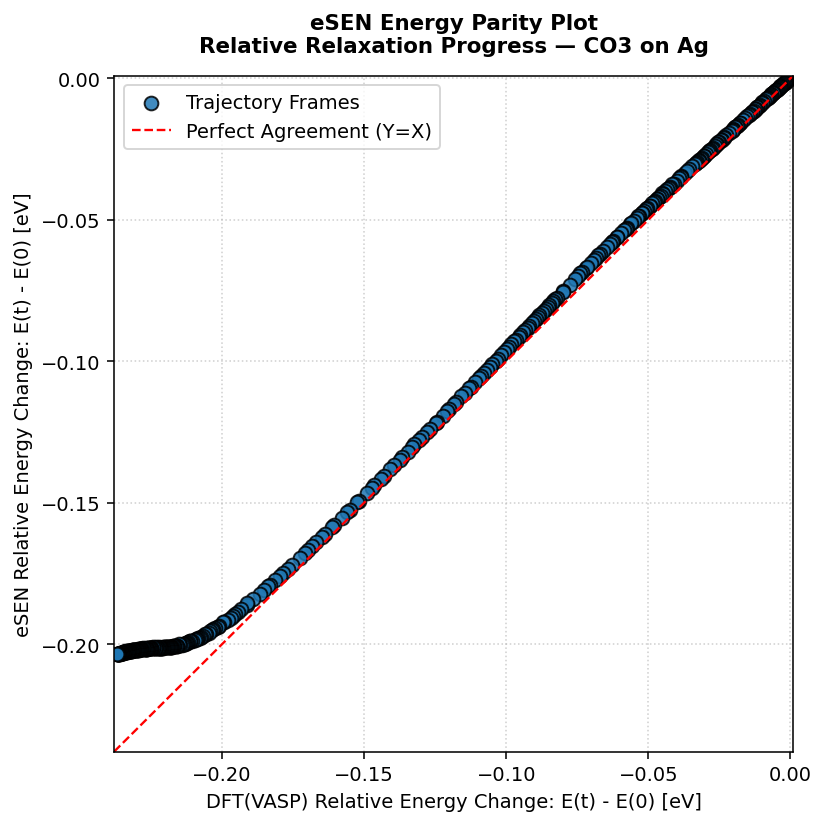

Saved: results\parity_UMA.png


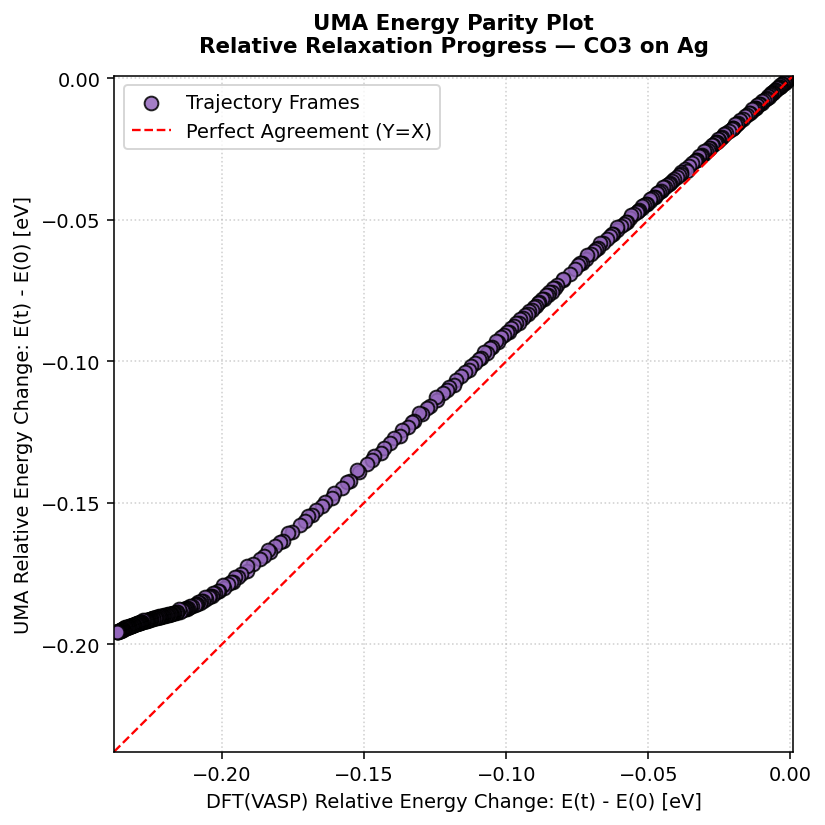

Saved: results\parity_Orb.png


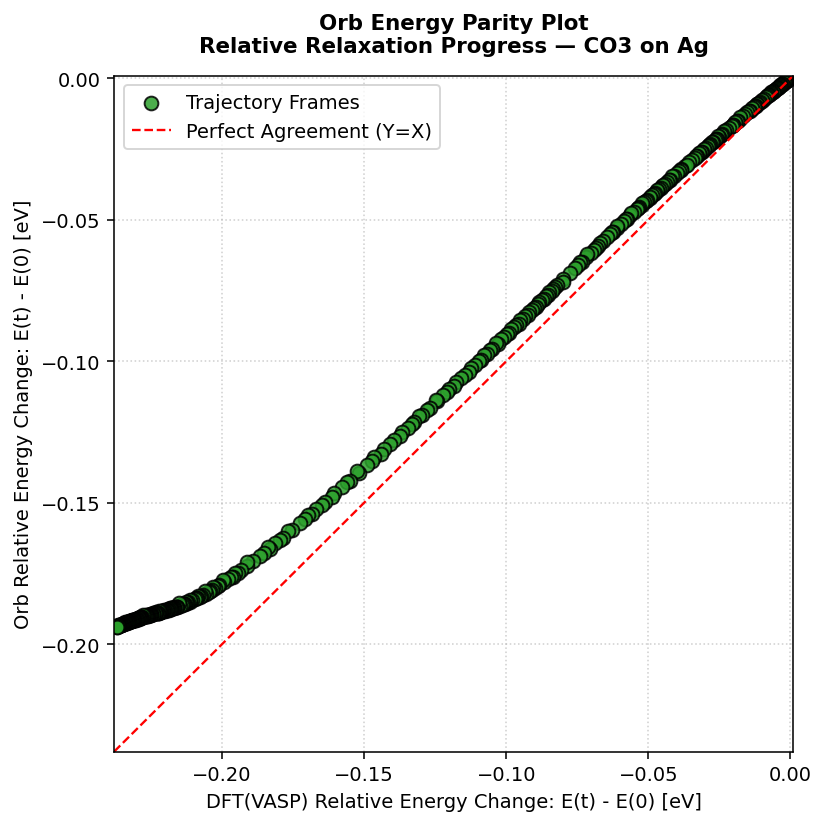

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Color scheme for each model
MODEL_COLORS  = {'eSEN': '#1f77b4', 'UMA': '#9467bd', 'Orb': '#2ca02c'}
MICRO_PADDING = 0.001

for model_name in active_models:
    dft_raw = results[model_name]['dft']
    ml_raw  = results[model_name]['ml']
    
    # Relative energy: subtract first frame from every frame
    x_dft_rel = dft_raw - dft_raw[0]
    y_ml_rel  = ml_raw  - ml_raw[0]
    
    color = MODEL_COLORS.get(model_name, '#1f77b4')
    
    # Set up the parity plot
    plt.figure(figsize=(6, 6), dpi=FIGURE_DPI)
    
    # Scatter plot: each point is one ionic step
    plt.scatter(
        x_dft_rel, y_ml_rel,
        color=color, alpha=0.85, edgecolors='k', s=50,
        label='Trajectory Frames', zorder=2
    )
    
    # Calculate tight zoom limits
    min_val = min(x_dft_rel.min(), y_ml_rel.min()) - MICRO_PADDING
    max_val = max(x_dft_rel.max(), y_ml_rel.max()) + MICRO_PADDING
    
    # Perfect agreement line (y = x)
    plt.plot(
        [min_val, max_val], [min_val, max_val],
        color='red', linestyle='--', linewidth=1.2,
        label='Perfect Agreement (Y=X)'
    )
    
    # Labels and formatting
    plt.title(
        f'{model_name} Energy Parity Plot\nRelative Relaxation Progress — {DATASET_LABEL}',
        fontsize=11, fontweight='bold', pad=12
    )
    plt.xlabel('DFT(VASP) Relative Energy Change: E(t) - E(0) [eV]', fontsize=10)
    plt.ylabel(f'{model_name} Relative Energy Change: E(t) - E(0) [eV]', fontsize=10)
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    
    # Save if requested
    if SAVE_PLOTS:
        fname = os.path.join(OUTPUT_DIR, f'parity_{model_name}.png')
        plt.savefig(fname, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f"Saved: {fname}")
    
    plt.show()

## Section 6 — Master comparison plot
All models side-by-side in one figure for direct comparison.

Saved: results\master_parity_comparison.png


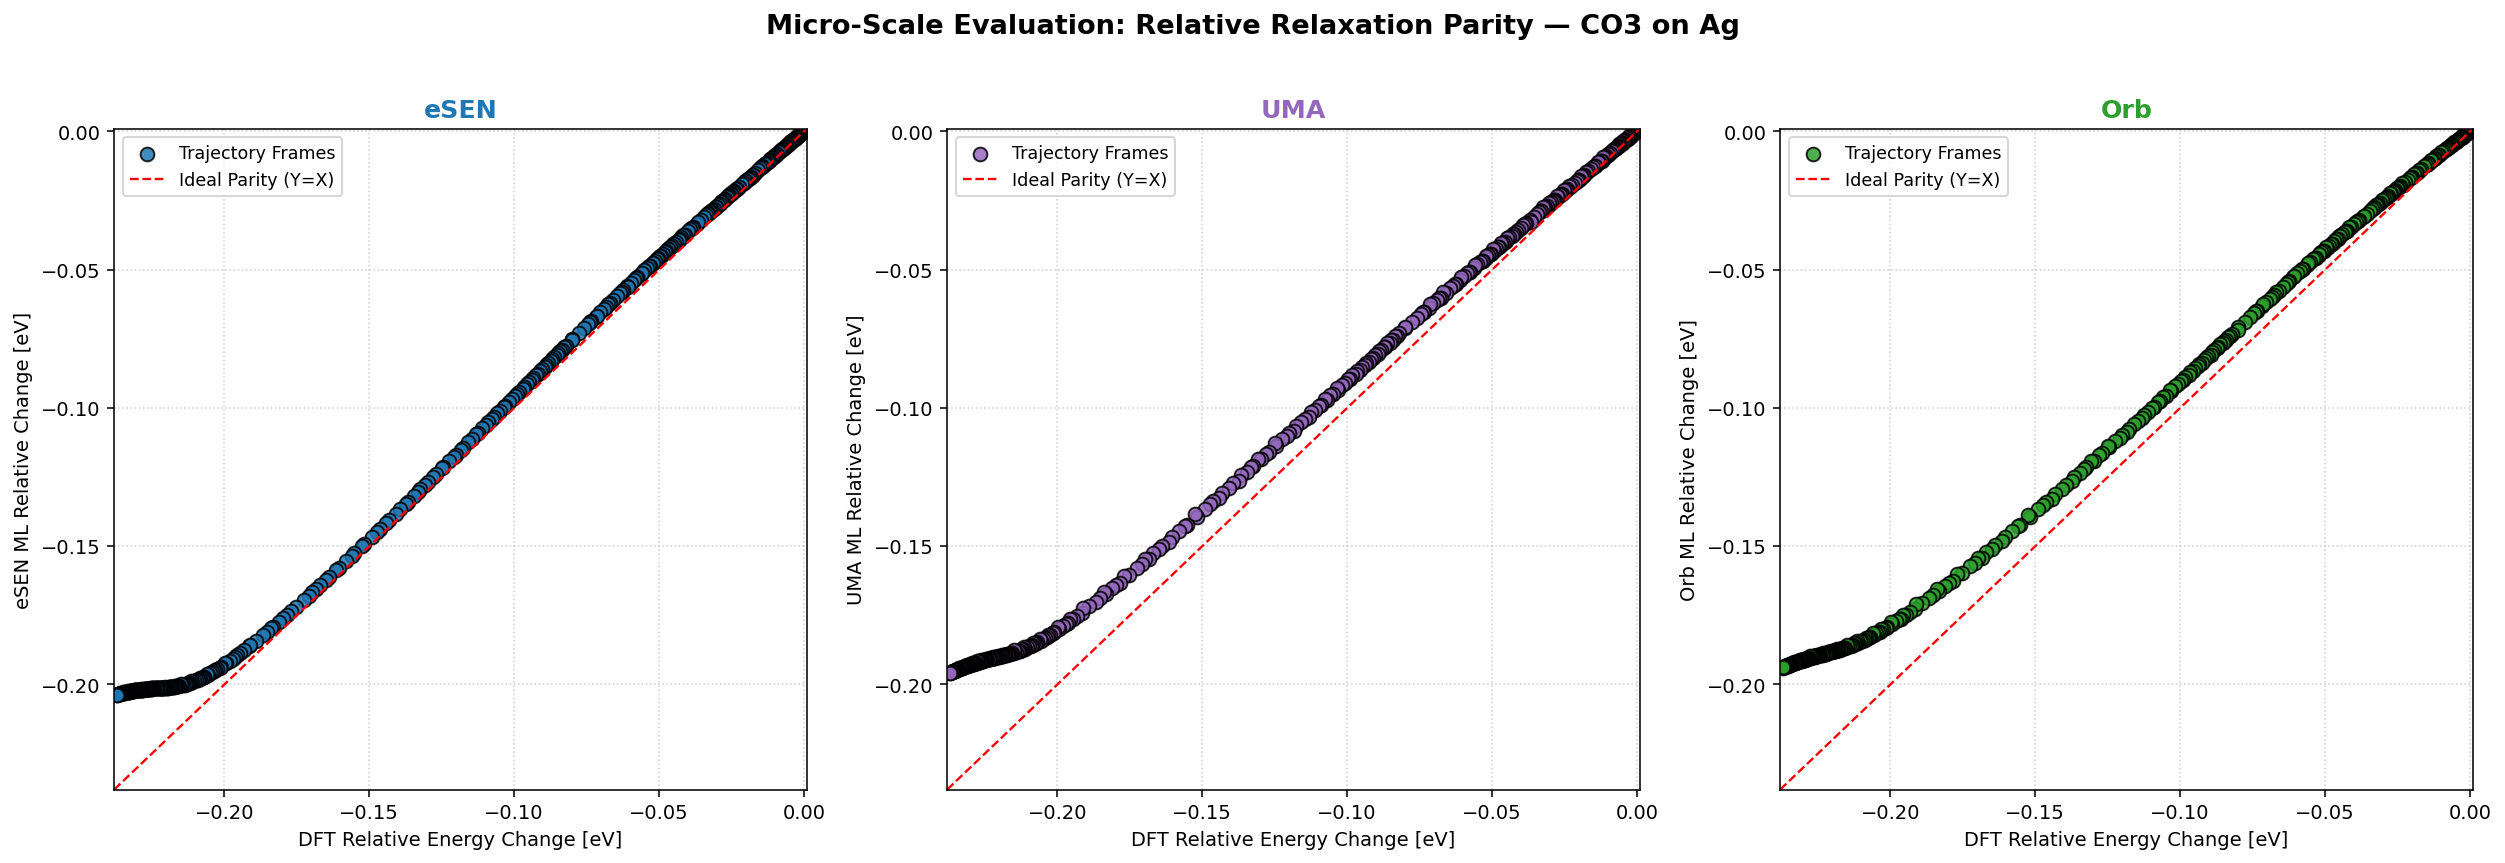

In [32]:
n_models = len(active_models)

if n_models == 0:
    print("No models to compare — check that at least one model ran successfully.")
else:
    fig, axes = plt.subplots(
        1, n_models,
        figsize=(6 * n_models, 6),
        dpi=FIGURE_DPI,
        squeeze=False
    )
    axes = axes[0]  # Flatten from 2D to 1D
    
    for ax, model_name in zip(axes, active_models):
        dft_raw = results[model_name]['dft']
        ml_raw  = results[model_name]['ml']
        
        # Relative energies
        x_rel = dft_raw - dft_raw[0]
        y_rel = ml_raw  - ml_raw[0]
        
        color = MODEL_COLORS.get(model_name, '#1f77b4')
        
        # Scatter plot
        ax.scatter(
            x_rel, y_rel,
            color=color, alpha=0.85, edgecolors='k', s=50,
            label='Trajectory Frames', zorder=2
        )
        
        # Tight zoom limits
        min_val = min(x_rel.min(), y_rel.min()) - MICRO_PADDING
        max_val = max(x_rel.max(), y_rel.max()) + MICRO_PADDING
        
        # y = x line
        ax.plot(
            [min_val, max_val], [min_val, max_val],
            color='red', linestyle='--', linewidth=1.2,
            label='Ideal Parity (Y=X)'
        )
        
        ax.set_title(model_name, fontsize=13, fontweight='bold', color=color)
        ax.set_xlabel('DFT Relative Energy Change [eV]', fontsize=10)
        ax.set_ylabel(f'{model_name} ML Relative Change [eV]', fontsize=10)
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper left', fontsize=9)
    
    fig.suptitle(
        f'Micro-Scale Evaluation: Relative Relaxation Parity — {DATASET_LABEL}',
        fontsize=14, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    
    if SAVE_PLOTS:
        fname = os.path.join(OUTPUT_DIR, 'master_parity_comparison.png')
        fig.savefig(fname, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f"Saved: {fname}")
    
    plt.show()

## Section 7 — Energy trajectory plot
Shows the total energy at each ionic step for DFT and all models overlaid.  
Useful for seeing where models diverge along the relaxation path.

Saved: results\energy_trajectory.png


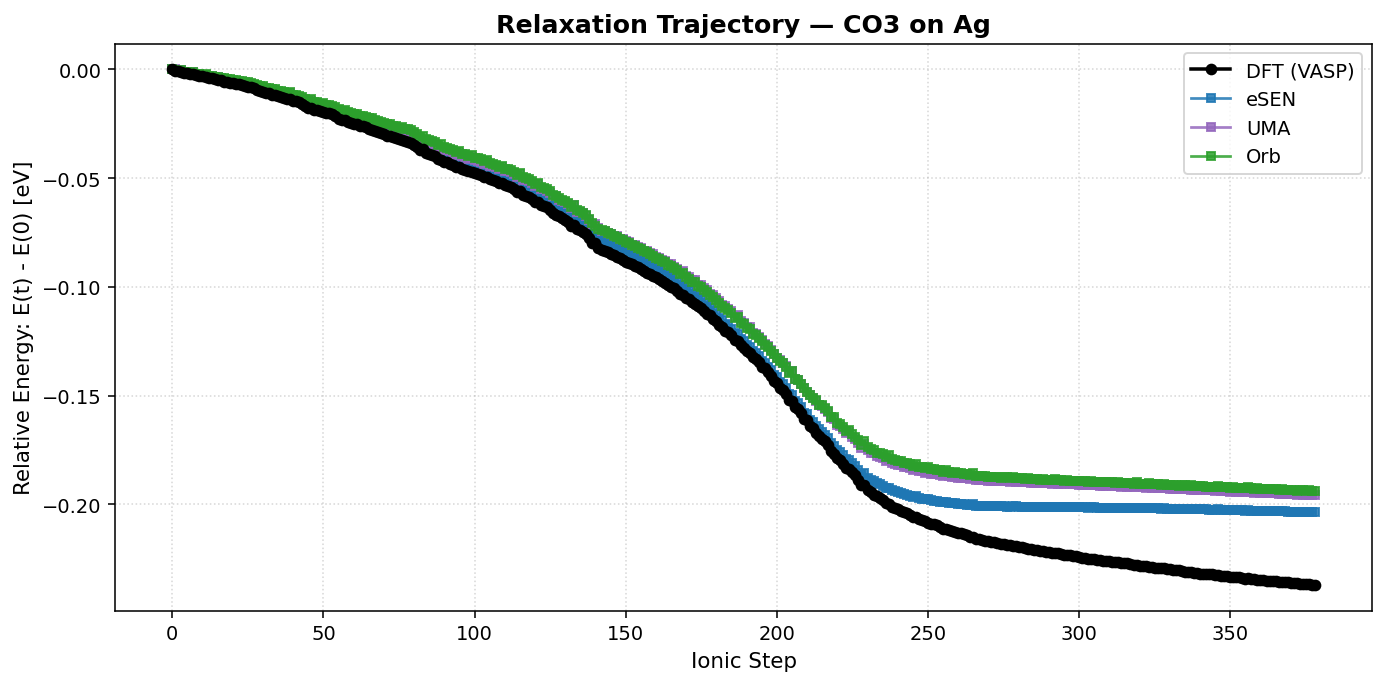

In [33]:
if len(active_models) > 0:
    fig, ax = plt.subplots(figsize=(10, 5), dpi=FIGURE_DPI)
    
    # Use DFT energies from the first active model (they're all from the same vasprun)
    first_model = active_models[0]
    dft = results[first_model]['dft']
    dft_rel = dft - dft[0]
    steps = np.arange(len(dft))
    
    # Plot DFT as the reference
    ax.plot(
        steps, dft_rel,
        'ko-', linewidth=1.8, markersize=5,
        label='DFT (VASP)', zorder=5
    )
    
    # Overlay each model
    for model_name in active_models:
        ml_raw = results[model_name]['ml']
        ml_rel = ml_raw - ml_raw[0]
        color  = MODEL_COLORS.get(model_name, 'steelblue')
        
        ax.plot(
            steps, ml_rel,
            marker='s', markersize=4, linewidth=1.4,
            color=color, alpha=0.85, label=model_name
        )
    
    ax.set_xlabel('Ionic Step', fontsize=11)
    ax.set_ylabel('Relative Energy: E(t) - E(0) [eV]', fontsize=11)
    ax.set_title(
        f'Relaxation Trajectory — {DATASET_LABEL}',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    
    if SAVE_PLOTS:
        fname = os.path.join(OUTPUT_DIR, 'energy_trajectory.png')
        fig.savefig(fname, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f"Saved: {fname}")
    
    plt.show()
else:
    print("No model results to plot.")

## Section 8 — Residuals plot
ΔE = ML_predicted − DFT at each ionic step.  
A flat line at 0 means the model perfectly tracks DFT.

Saved: results\residuals.png


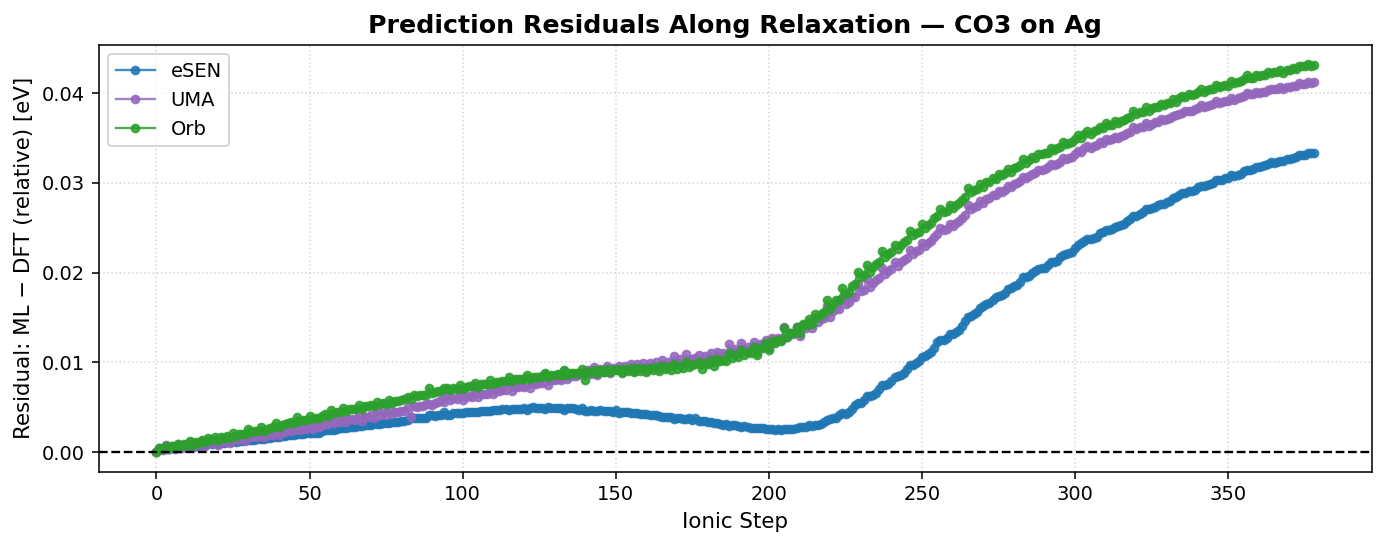

In [34]:
if len(active_models) > 0:
    fig, ax = plt.subplots(figsize=(10, 4), dpi=FIGURE_DPI)
    
    first_model = active_models[0]
    dft = results[first_model]['dft']
    dft_rel = dft - dft[0]
    steps = np.arange(len(dft))
    
    for model_name in active_models:
        ml_raw = results[model_name]['ml']
        ml_rel = ml_raw - ml_raw[0]
        residuals = ml_rel - dft_rel  # How far the model is from DFT
        color = MODEL_COLORS.get(model_name, 'steelblue')
        
        ax.plot(
            steps, residuals,
            marker='o', markersize=4, linewidth=1.2,
            color=color, alpha=0.85, label=model_name
        )
    
    # Zero line = perfect agreement
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    
    ax.set_xlabel('Ionic Step', fontsize=11)
    ax.set_ylabel('Residual: ML − DFT (relative) [eV]', fontsize=11)
    ax.set_title(
        f'Prediction Residuals Along Relaxation — {DATASET_LABEL}',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    
    if SAVE_PLOTS:
        fname = os.path.join(OUTPUT_DIR, 'residuals.png')
        fig.savefig(fname, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f"Saved: {fname}")
    
    plt.show()
else:
    print("No model results to plot.")

## Section 9 — Metrics table
MAE, RMSE, R², and Pearson r computed on the **relative** energy changes.

In [35]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

if len(active_models) > 0:
    metrics_records = []
    
    for model_name in active_models:
        dft_raw = results[model_name]['dft']
        ml_raw  = results[model_name]['ml']
        
        # Relative energies (subtract first frame)
        dft_rel = dft_raw - dft_raw[0]
        ml_rel  = ml_raw  - ml_raw[0]
        
        # Mean Absolute Error
        mae = mean_absolute_error(dft_rel, ml_rel)
        
        # Root Mean Squared Error
        rmse = np.sqrt(np.mean((ml_rel - dft_rel) ** 2))
        
        # R-squared
        if len(dft_rel) < 2 or np.all(dft_rel == dft_rel[0]):
            r2 = np.nan
        else:
            r2 = r2_score(dft_rel, ml_rel)
        
        # Pearson correlation coefficient
        if len(dft_rel) < 2:
            pearson_r = np.nan
        else:
            pearson_r = np.corrcoef(dft_rel, ml_rel)[0, 1]
        
        # Mean signed error (bias)
        bias = np.mean(ml_rel - dft_rel)
        
        # Max absolute error
        max_ae = np.max(np.abs(ml_rel - dft_rel))
        
        metrics_records.append({
            'Model':            model_name,
            'N frames':         len(dft_rel),
            'MAE (eV)':         round(mae, 6),
            'RMSE (eV)':        round(rmse, 6),
            'R²':               round(r2, 4) if not np.isnan(r2) else 'N/A',
            'Pearson r':        round(pearson_r, 4) if not np.isnan(pearson_r) else 'N/A',
            'Bias (eV)':        round(bias, 6),
            'Max |ΔE| (eV)':    round(max_ae, 6),
        })
    
    metrics_df = pd.DataFrame(metrics_records).set_index('Model')
    
    print(f"=== Relative Energy Metrics (vs DFT) — {DATASET_LABEL} ===")
    print()
    display(metrics_df)
    
    # Save metrics to CSV
    csv_path = os.path.join(OUTPUT_DIR, 'metrics_summary.csv')
    metrics_df.to_csv(csv_path)
    print(f"\nMetrics saved to {csv_path}")
else:
    print("No model results to compute metrics.")

=== Relative Energy Metrics (vs DFT) — CO3 on Ag ===



,N frames,MAE (eV),RMSE (eV),R²,Pearson r,Bias (eV),Max |ΔE| (eV)
Model,,,,,,,
eSEN,379,0.010617,0.015031,0.9695,0.9968,0.010617,0.033351
UMA,379,0.017077,0.021765,0.9360,0.9981,0.017077,0.041242
Orb,379,0.018041,0.022884,0.9293,0.9978,0.018041,0.043239



Metrics saved to results\metrics_summary.csv


## Section 10 — Export all results to CSV
One clean CSV file with DFT and all model predictions at each ionic step.

In [ ]:
if len(active_models) > 0:
    # Use DFT from first model (all read the same vasprun)
    first_model = active_models[0]
    dft = results[first_model]['dft']
    n_frames = len(dft)
    
    export_data = {
        'step':              np.arange(n_frames),
        'DFT_energy_eV':     dft,
        'DFT_relative_eV':   dft - dft[0],
    }
    
    for model_name in active_models:
        ml = results[model_name]['ml']
        export_data[f'{model_name}_energy_eV']   = ml
        export_data[f'{model_name}_relative_eV'] = ml - ml[0]
        export_data[f'{model_name}_error_eV']    = (ml - ml[0]) - (dft - dft[0])
    
    export_df = pd.DataFrame(export_data)
    
    csv_path = os.path.join(OUTPUT_DIR, 'full_results.csv')
    export_df.to_csv(csv_path, index=False)
    
    print(f"Full results saved to {csv_path}")
    print(f"\nFirst 10 rows:")
    display(export_df.head(10))
else:
    print("No results to export.")

---
# Experiment 2 — Self-Relaxation Comparison

Everything above (Sections 1–10) is **Experiment 1**: each model saw every DFT  
geometry and only predicted the energy for each fixed frame.

The sections below analyze **Experiment 2**: each model was given **only the  
first frame's geometry**, then relaxed the structure *itself* (predicting its  
own forces and moving the atoms) until forces dropped below the convergence  
threshold. This is the harder, more realistic test — it asks whether a model  
can find the same energy minimum and final geometry that VASP's DFT found,  
without being shown the path.

We compare three things:
1. **Final relaxed energy**: MLIP-relaxed vs DFT-relaxed (relative to first frame)
2. **Final geometry**: RMSD between MLIP-relaxed and DFT-relaxed structures
3. **Relaxation path**: how each model's self-driven trajectory compares to DFT's

These cells only run if `RUN_RELAXATION = True` was set in Section 0.

## Section 11 — Self-relaxation energy summary
How close did each model's self-relaxed final energy land to DFT's total  
relaxation energy change? Compares the final E(t) - E(0) values.

In [36]:
if len(relaxed_models) > 0:
    # DFT's total relaxation energy change (same for all models — same vasprun)
    dft_ref = results[relaxed_models[0]]['dft']
    dft_total_change = dft_ref[-1] - dft_ref[0]
    
    print(f"DFT total relaxation energy change: {dft_total_change:.4f} eV")
    print(f"(from frame 0 to frame {len(dft_ref)-1})\n")
    
    relax_records = []
    for model_name in relaxed_models:
        relax_e = results[model_name]['relax_energies']
        
        # The model's own total energy change during ITS relaxation
        ml_total_change = relax_e[-1] - relax_e[0]
        
        # Difference between the model's relaxation depth and DFT's
        energy_diff = ml_total_change - dft_total_change
        
        relax_records.append({
            'Model':                    model_name,
            'Relax steps':              results[model_name]['relax_n_steps'],
            'Converged':                results[model_name]['relax_converged'],
            'MLIP ΔE (eV)':             round(ml_total_change, 4),
            'DFT ΔE (eV)':              round(dft_total_change, 4),
            'ΔE difference (eV)':       round(energy_diff, 4),
        })
    
    relax_df = pd.DataFrame(relax_records).set_index('Model')
    print("=== Self-Relaxation Energy Summary ===")
    print()
    display(relax_df)
    
    # A model that didn't converge within MAX_RELAX_STEPS should be read with caution
    not_converged = [m for m in relaxed_models if not results[m]['relax_converged']]
    if not_converged:
        print(f"\n⚠️  These models did NOT converge within the step cap: {not_converged}")
        print("   Their results may not represent a true energy minimum.")
        print("   Consider raising MAX_RELAX_STEPS in Section 0.")
    
    # Save to CSV
    csv_path = os.path.join(OUTPUT_DIR, 'relaxation_energy_summary.csv')
    relax_df.to_csv(csv_path)
    print(f"\nSaved to {csv_path}")
else:
    print("No self-relaxation data found.")
    print("Set RUN_RELAXATION = True in Section 0 and re-run the model cells.")

DFT total relaxation energy change: -0.2370 eV
(from frame 0 to frame 378)

=== Self-Relaxation Energy Summary ===



,Relax steps,Converged,MLIP ΔE (eV),DFT ΔE (eV),ΔE difference (eV)
Model,,,,,
eSEN,77,True,-0.3082,-0.237,-0.0712
UMA,74,True,-0.2582,-0.237,-0.0212
Orb,70,True,-0.2551,-0.237,-0.0181



Saved to results\relaxation_energy_summary.csv


## Section 12 — Final geometry comparison (RMSD)
Root-mean-square deviation between each model's self-relaxed final structure  
and the DFT-relaxed final structure. Lower RMSD = the model found a geometry  
closer to DFT's answer.

RMSD here is computed atom-by-atom on the raw coordinates (no alignment),  
which is appropriate because all structures share the same fixed cell and the  
bottom slab layers are constrained, so they're already in a common frame.

In [37]:
if len(relaxed_models) > 0:
    rmsd_records = []
    
    for model_name in relaxed_models:
        ml_pos  = results[model_name]['relax_final_positions']
        dft_pos = results[model_name]['dft_final_positions']
        
        # Safety check: same number of atoms
        if ml_pos.shape != dft_pos.shape:
            print(f"⚠️  {model_name}: position arrays differ in shape, skipping.")
            continue
        
        # Per-atom displacement between MLIP-relaxed and DFT-relaxed structures
        displacements = ml_pos - dft_pos
        per_atom_dist = np.sqrt((displacements ** 2).sum(axis=1))
        
        # RMSD = root mean square of per-atom distances
        rmsd = np.sqrt(np.mean(per_atom_dist ** 2))
        # Largest single-atom movement away from the DFT position
        max_dev = per_atom_dist.max()
        
        rmsd_records.append({
            'Model':              model_name,
            'RMSD (Å)':           round(rmsd, 4),
            'Max atom dev (Å)':   round(max_dev, 4),
        })
    
    rmsd_df = pd.DataFrame(rmsd_records).set_index('Model')
    print("=== Final Geometry Comparison: MLIP-relaxed vs DFT-relaxed ===")
    print()
    display(rmsd_df)
    
    csv_path = os.path.join(OUTPUT_DIR, 'relaxation_rmsd.csv')
    rmsd_df.to_csv(csv_path)
    print(f"\nSaved to {csv_path}")
else:
    print("No self-relaxation data found.")

=== Final Geometry Comparison: MLIP-relaxed vs DFT-relaxed ===



,RMSD (Å),Max atom dev (Å)
Model,,
eSEN,0.2055,0.4261
UMA,0.1921,0.3754
Orb,0.1753,0.3437



Saved to results\relaxation_rmsd.csv


## Section 13 — Relaxation trajectory plot
Each model's self-driven relaxation path (energy vs its own optimizer step),  
with DFT's relaxation path shown for reference. Note the x-axes aren't the same  
physical steps — DFT and each model take different numbers of steps — but this  
shows the shape and depth of each relaxation.

Saved: results\self_relaxation_paths.png


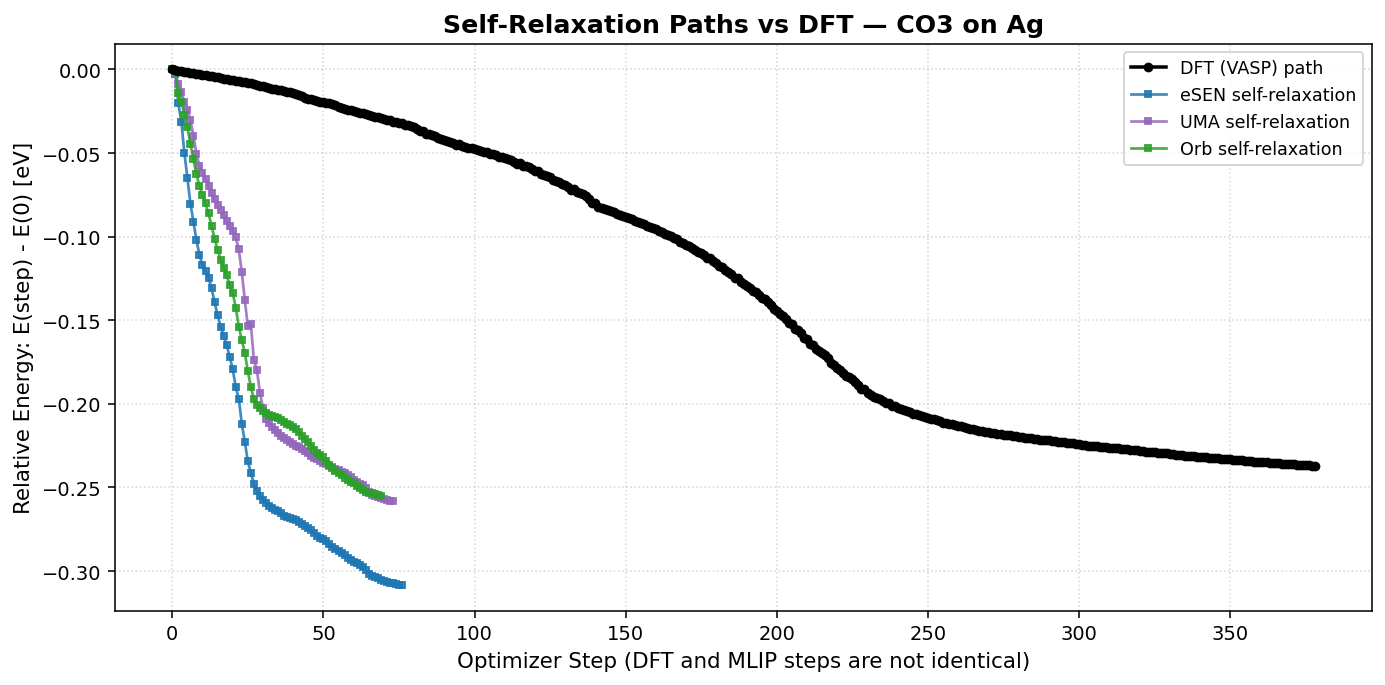

In [38]:
if len(relaxed_models) > 0:
    fig, ax = plt.subplots(figsize=(10, 5), dpi=FIGURE_DPI)
    
    # DFT relaxation path (relative to its own first frame)
    dft_ref = results[relaxed_models[0]]['dft']
    dft_rel = dft_ref - dft_ref[0]
    ax.plot(
        np.arange(len(dft_rel)), dft_rel,
        'ko-', linewidth=1.8, markersize=4,
        label='DFT (VASP) path', zorder=5
    )
    
    # Each model's self-relaxation path (relative to its own first frame)
    for model_name in relaxed_models:
        relax_e = results[model_name]['relax_energies']
        relax_rel = relax_e - relax_e[0]
        color = MODEL_COLORS.get(model_name, 'steelblue')
        ax.plot(
            np.arange(len(relax_rel)), relax_rel,
            marker='s', markersize=3, linewidth=1.4,
            color=color, alpha=0.85,
            label=f'{model_name} self-relaxation'
        )
    
    ax.set_xlabel('Optimizer Step (DFT and MLIP steps are not identical)', fontsize=11)
    ax.set_ylabel('Relative Energy: E(step) - E(0) [eV]', fontsize=11)
    ax.set_title(
        f'Self-Relaxation Paths vs DFT — {DATASET_LABEL}',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    
    if SAVE_PLOTS:
        fname = os.path.join(OUTPUT_DIR, 'self_relaxation_paths.png')
        fig.savefig(fname, dpi=FIGURE_DPI, bbox_inches='tight')
        print(f"Saved: {fname}")
    
    plt.show()
else:
    print("No self-relaxation data to plot.")

## Section 14 — Experiment 1 vs Experiment 2 side-by-side
The key payoff: for each model, compare the final energy error from the  
single-point experiment (model saw every DFT frame) against the self-relaxation  
experiment (model only saw the first frame). If a model does well on  
single-point but poorly on self-relaxation, it can score known geometries but  
can't reliably find the minimum on its own.

In [39]:
if len(relaxed_models) > 0:
    combined_records = []
    
    dft_ref = results[relaxed_models[0]]['dft']
    dft_total_change = dft_ref[-1] - dft_ref[0]
    
    for model_name in relaxed_models:
        # Experiment 1: single-point final relative-energy error
        dft_raw = results[model_name]['dft']
        ml_raw  = results[model_name]['ml']
        sp_final_error = (ml_raw[-1] - ml_raw[0]) - (dft_raw[-1] - dft_raw[0])
        
        # Experiment 2: self-relaxation final energy-change error
        relax_e = results[model_name]['relax_energies']
        relax_final_error = (relax_e[-1] - relax_e[0]) - dft_total_change
        
        # Geometry agreement (RMSD)
        ml_pos  = results[model_name]['relax_final_positions']
        dft_pos = results[model_name]['dft_final_positions']
        if ml_pos.shape == dft_pos.shape:
            rmsd = np.sqrt(np.mean(((ml_pos - dft_pos) ** 2).sum(axis=1)))
        else:
            rmsd = np.nan
        
        combined_records.append({
            'Model':                       model_name,
            'Exp1 single-pt ΔE err (eV)':  round(sp_final_error, 4),
            'Exp2 self-relax ΔE err (eV)': round(relax_final_error, 4),
            'Exp2 geometry RMSD (Å)':      round(rmsd, 4) if not np.isnan(rmsd) else 'N/A',
            'Converged':                   results[model_name]['relax_converged'],
        })
    
    combined_df = pd.DataFrame(combined_records).set_index('Model')
    print(f"=== Experiment 1 vs Experiment 2 — {DATASET_LABEL} ===")
    print()
    display(combined_df)
    
    csv_path = os.path.join(OUTPUT_DIR, 'experiment1_vs_experiment2.csv')
    combined_df.to_csv(csv_path)
    print(f"\nSaved to {csv_path}")
    print("\nHow to read this table:")
    print("  • Exp1 error small, Exp2 error small  → model both scores and relaxes well")
    print("  • Exp1 error small, Exp2 error large  → good at scoring, poor at finding the minimum")
    print("  • Low RMSD                            → model's relaxed structure matches DFT's")
else:
    print("No self-relaxation data found.")
    print("Set RUN_RELAXATION = True in Section 0 and re-run the model cells.")

=== Experiment 1 vs Experiment 2 — CO3 on Ag ===



,Exp1 single-pt ΔE err (eV),Exp2 self-relax ΔE err (eV),Exp2 geometry RMSD (Å),Converged
Model,,,,
eSEN,0.0334,-0.0712,0.2055,True
UMA,0.0412,-0.0212,0.1921,True
Orb,0.0432,-0.0181,0.1753,True



Saved to results\experiment1_vs_experiment2.csv

How to read this table:
  • Exp1 error small, Exp2 error small  → model both scores and relaxes well
  • Exp1 error small, Exp2 error large  → good at scoring, poor at finding the minimum
  • Low RMSD                            → model's relaxed structure matches DFT's
